# 🔴 The Complete Pokédex — EDA of all 1,025 Pokémon

A clean, reproducible starter analysis of **every released Pokémon, Gen I–IX**
(#0001 Bulbasaur → #1025 Pecharunt). Fork it, run it top to bottom, and build on it.

**Contents**
1. [Setup & load](#1)
2. [Dataset at a glance](#2)
3. [Type distribution](#3)
4. [Base-stat distributions](#4)
5. [Legendary vs. ordinary Pokémon](#5)
6. [Trends across generations](#6)
7. [How base stats relate](#7)
8. [Type-defence profile](#8)
9. [Strongest & frailest Pokémon](#9)
10. [Takeaways & next steps](#10)

> Data: `pokemon_utf8.csv` — 1,025 rows × 55 columns (identity, types, base stats,
> abilities, gender, breeding, 18 type-matchup multipliers, legendary flags,
> evolution chains, Mega/Gigantamax forms, and official Pokédex text).

<a id="1"></a>
## 1. Setup & load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- a calm, readable house style (validated data-viz ink/grid) -------------
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, RED, AQUA, VIOLET = "#2a78d6", "#e34948", "#1baf7a", "#4a3aa7"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.linewidth": 1,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelcolor": INK2, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "font.size": 11, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})

# Canonical Pokémon type colours — an identity mapping the audience already knows.
TYPE_COLORS = {
    "normal":"#A8A77A","fire":"#EE8130","water":"#6390F0","electric":"#F7D02C",
    "grass":"#7AC74C","ice":"#96D9D6","fighting":"#C22E28","poison":"#A33EA1",
    "ground":"#E2BF65","flying":"#A98FF3","psychic":"#F95587","bug":"#A6B91A",
    "rock":"#B6A136","ghost":"#735797","dragon":"#6F35FC","dark":"#705746",
    "steel":"#B7B7CE","fairy":"#D685AD",
}
STATS = ["hp","attack","defense","sp_attack","sp_defense","speed"]
GEN_ORDER = ["I","II","III","IV","V","VI","VII","VIII","IX"]

# UTF-8 comma CSV loads with a plain read_csv. (The UTF-16 pokemon.csv holds the
# same data: pd.read_csv('pokemon.csv', encoding='utf-16', sep='\t').)
df = pd.read_csv("/kaggle/input/pokedex/pokemon_utf8.csv")
df["total"] = df[STATS].sum(axis=1)
print(df.shape)
df.head()

(1025, 56)


,national_number,gen,english_name,japanese_name,primary_type,secondary_type,classification,percent_male,percent_female,height_m,...,evochain_2,evochain_3,evochain_4,evochain_5,evochain_6,gigantamax,mega_evolution,mega_evolution_alt,description,total
0,1,I,Bulbasaur,Fushigidane,grass,poison,Seed Pokémon,87.5,12.5,0.7,...,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,There is a plant seed on its back right from t...,318
1,2,I,Ivysaur,Fushigisou,grass,poison,Seed Pokémon,87.5,12.5,1.0,...,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,"When the bulb on its back grows large, it appe...",405
2,3,I,Venusaur,Fushigibana,grass,poison,Seed Pokémon,87.5,12.5,2.0,...,Ivysaur,Level,Venusaur,NaN,NaN,Gigantamax Venusaur,Mega Venusaur,NaN,Its plant blooms when it is absorbing solar en...,525
3,4,I,Charmander,Hitokage,fire,NaN,Lizard Pokémon,87.5,12.5,0.6,...,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,It has a preference for hot things. When it ra...,309
4,5,I,Charmeleon,Lizardo,fire,NaN,Flame Pokémon,87.5,12.5,1.1,...,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,"It has a barbaric nature. In battle, it whips ...",405


<a id="2"></a>
## 2. Dataset at a glance

In [2]:
print(f"Pokémon (rows):   {len(df):,}")
print(f"Features (cols):  {df.shape[1]}")
print(f"National range:   #{df.national_number.min()} – #{df.national_number.max()}")
print(f"Generations:      {df.gen.nunique()}  ({', '.join(GEN_ORDER)})")
print(f"Legendary:        {int(df.is_legendary.sum())}   "
      f"Sub-legendary: {int(df.is_sublegendary.sum())}   "
      f"Mythical: {int(df.is_mythical.sum())}")
print(f"Mega-capable:     {df.mega_evolution.notna().sum()}   "
      f"Gigantamax: {df.gigantamax.notna().sum()}")
print(f"Dual-typed:       {df.secondary_type.notna().sum()}   "
      f"Mono-typed: {df.secondary_type.isna().sum()}")

Pokémon (rows):   1,025
Features (cols):  56
National range:   #1 – #1025
Generations:      9  (I, II, III, IV, V, VI, VII, VIII, IX)
Legendary:        23   Sub-legendary: 54   Mythical: 21
Mega-capable:     87   Gigantamax: 32
Dual-typed:       526   Mono-typed: 499


In [3]:
# Missing values are meaningful here (blank = "not applicable"), not dirty data.
miss = (df.isna().mean()*100).round(1)
miss[miss > 0].sort_values(ascending=False).to_frame("percent_missing")

,percent_missing
abilities_2,99.7
mega_evolution_alt,99.4
evochain_5,97.9
evochain_6,97.9
gigantamax,96.9
mega_evolution,91.5
evochain_4,63.0
evochain_3,62.7
secondary_type,48.7
abilities_1,47.0


<a id="3"></a>
## 3. Type distribution
Bars are sorted and carry the type name, so identity never rests on colour alone.

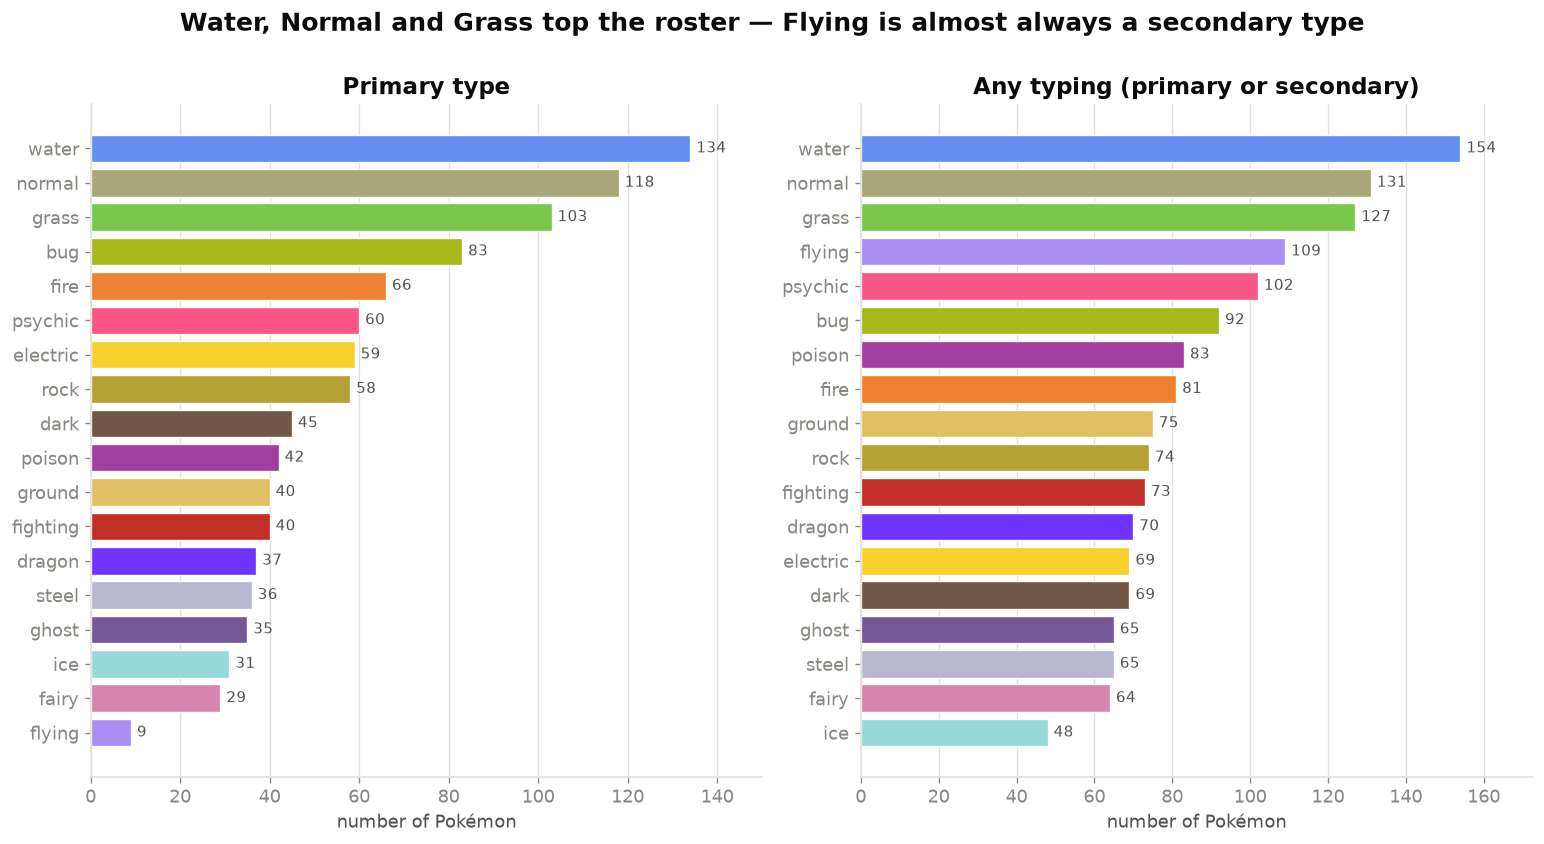

In [4]:
prim = df.primary_type.value_counts()
# combined primary+secondary presence, for "how common is each type overall"
combined = (pd.concat([df.primary_type, df.secondary_type.dropna()])
              .value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, data, title in [
    (axes[0], prim, "Primary type"),
    (axes[1], combined, "Any typing (primary or secondary)"),
]:
    data = data.sort_values()
    ax.barh(data.index, data.values,
            color=[TYPE_COLORS[t] for t in data.index],
            edgecolor="white", linewidth=0.8)
    for i, v in enumerate(data.values):
        ax.text(v + max(data.values)*0.01, i, str(v), va="center",
                fontsize=9, color=INK2)
    ax.set_title(title); ax.set_xlabel("number of Pokémon")
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.12)
fig.suptitle("Water, Normal and Grass top the roster — Flying is almost always a secondary type",
             fontsize=15, fontweight="bold", color=INK, x=0.5, y=1.0)
plt.tight_layout(); plt.show()

<a id="4"></a>
## 4. Base-stat distributions
Each of the six base stats, plus the base-stat total.

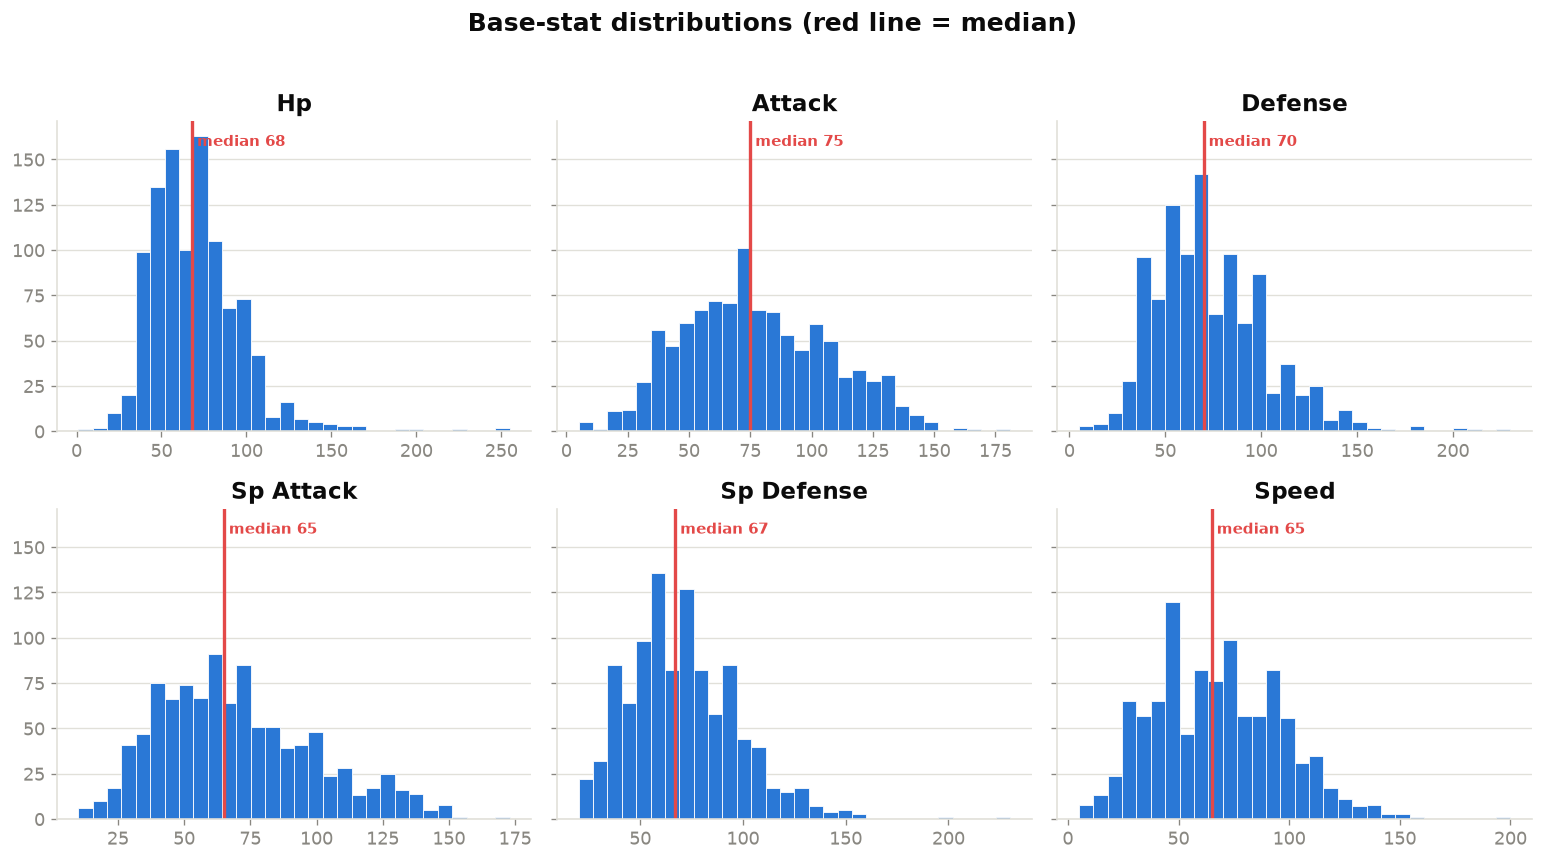

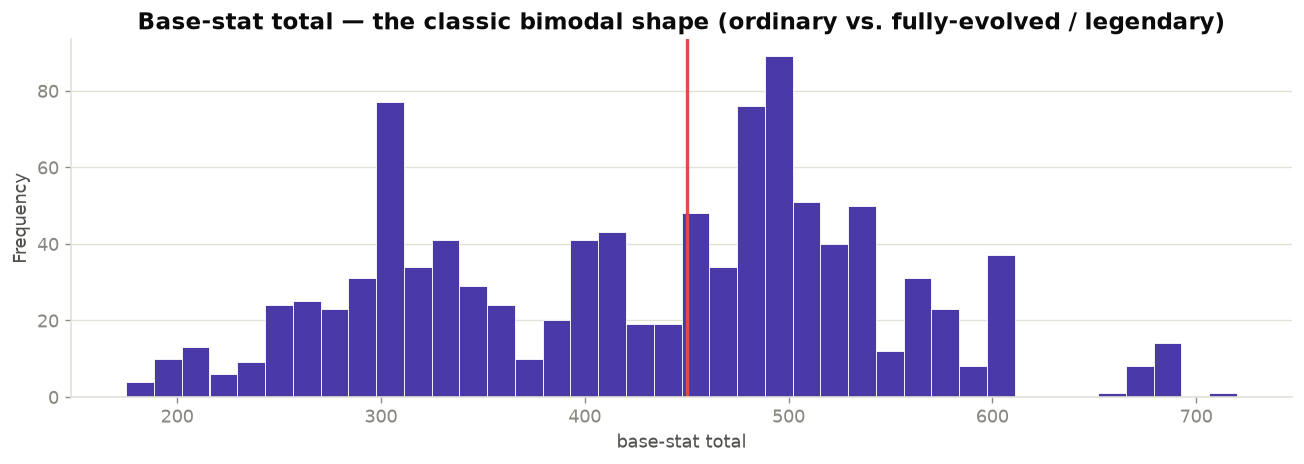

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, stat in zip(axes.ravel(), STATS):
    ax.hist(df[stat], bins=30, color=BLUE, edgecolor="white", linewidth=0.5)
    med = df[stat].median()
    ax.axvline(med, color=RED, linewidth=2)
    ax.text(med, ax.get_ylim()[1]*0.92, f" median {med:.0f}",
            color=RED, fontsize=9, fontweight="bold")
    ax.set_title(stat.replace("_", " ").title())
    ax.grid(axis="x", visible=False)
fig.suptitle("Base-stat distributions (red line = median)",
             fontsize=15, fontweight="bold", color=INK, y=1.02)
plt.tight_layout(); plt.show()

ax = df["total"].plot.hist(bins=40, figsize=(11, 4), color=VIOLET,
                           edgecolor="white", linewidth=0.5)
ax.axvline(df["total"].median(), color=RED, linewidth=2)
ax.set_title("Base-stat total — the classic bimodal shape "
             "(ordinary vs. fully-evolved / legendary)")
ax.set_xlabel("base-stat total"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

<a id="5"></a>
## 5. Legendary vs. ordinary Pokémon

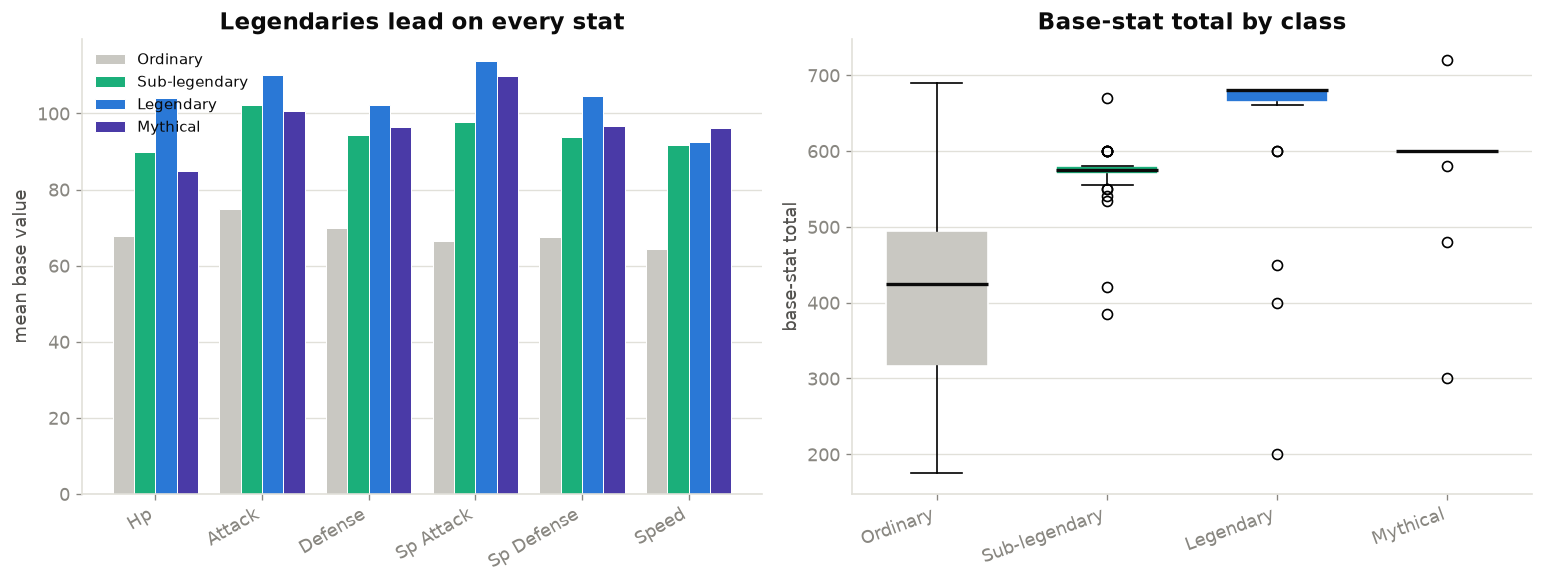

In [6]:
df["class"] = np.select(
    [df.is_mythical == 1, df.is_legendary == 1, df.is_sublegendary == 1],
    ["Mythical", "Legendary", "Sub-legendary"], default="Ordinary")
order = ["Ordinary", "Sub-legendary", "Legendary", "Mythical"]
CLASS_C = {"Ordinary": "#c9c8c2", "Sub-legendary": AQUA,
           "Legendary": BLUE, "Mythical": VIOLET}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# (a) mean base stat by group, grouped bars
means = df.groupby("class")[STATS].mean().reindex(order)
x = np.arange(len(STATS)); w = 0.2
for i, cls in enumerate(order):
    axes[0].bar(x + (i-1.5)*w, means.loc[cls], w, label=cls,
                color=CLASS_C[cls], edgecolor="white", linewidth=0.6)
axes[0].set_xticks(x); axes[0].set_xticklabels(
    [s.replace("_", " ").title() for s in STATS], rotation=30, ha="right")
axes[0].set_title("Legendaries lead on every stat"); axes[0].set_ylabel("mean base value")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(axis="x", visible=False)
# (b) distribution of base-stat total per group
data = [df.loc[df["class"] == c, "total"] for c in order]
bp = axes[1].boxplot(data, patch_artist=True, widths=0.6,
                     medianprops=dict(color=INK, linewidth=2))
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(CLASS_C[c]); patch.set_edgecolor("white")
axes[1].set_xticks(range(1, len(order)+1))
axes[1].set_xticklabels(order, rotation=20, ha="right")
axes[1].set_title("Base-stat total by class")
axes[1].set_ylabel("base-stat total"); axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

<a id="6"></a>
## 6. Trends across generations

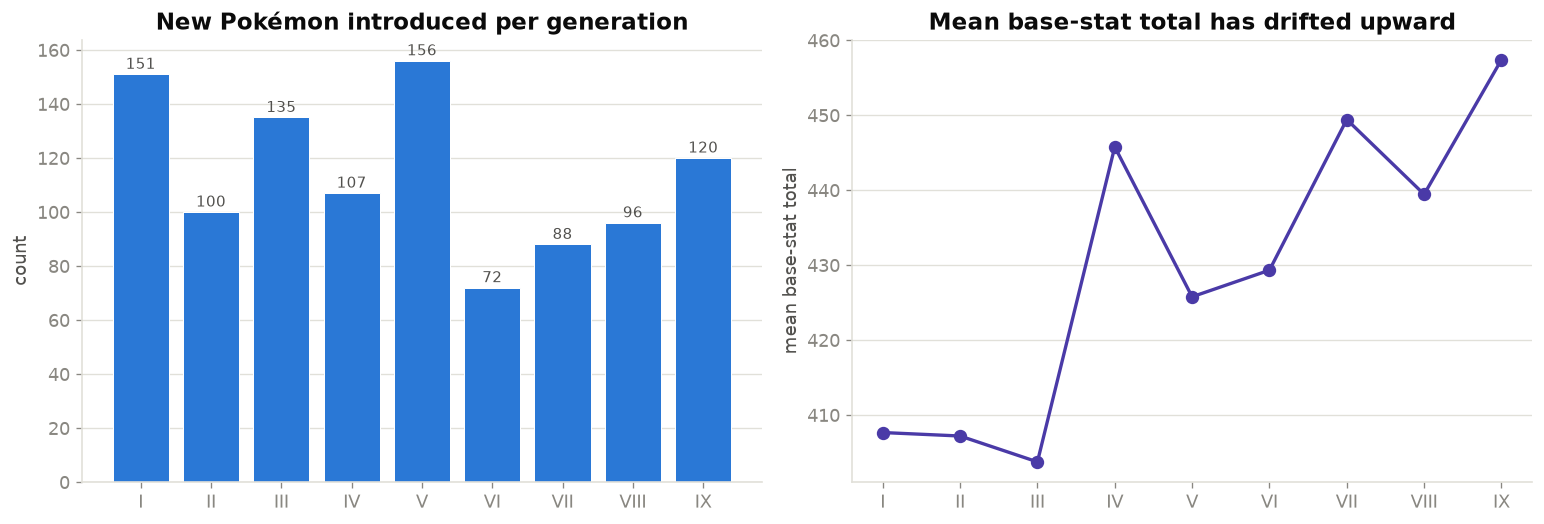

In [7]:
g_count = df.gen.value_counts().reindex(GEN_ORDER)
g_total = df.groupby("gen")["total"].mean().reindex(GEN_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(GEN_ORDER, g_count.values, color=BLUE,
            edgecolor="white", linewidth=0.6)
for i, v in enumerate(g_count.values):
    axes[0].text(i, v + 2, str(int(v)), ha="center", fontsize=9, color=INK2)
axes[0].set_title("New Pokémon introduced per generation")
axes[0].set_ylabel("count"); axes[0].grid(axis="x", visible=False)

axes[1].plot(GEN_ORDER, g_total.values, marker="o", color=VIOLET,
             linewidth=2, markersize=7)
axes[1].set_title("Mean base-stat total has drifted upward")
axes[1].set_ylabel("mean base-stat total")
axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

<a id="7"></a>
## 7. How base stats relate
Correlation spans −1…+1, so this uses a **diverging** blue↔red scale with a neutral-grey midpoint (grey = no linear relationship).

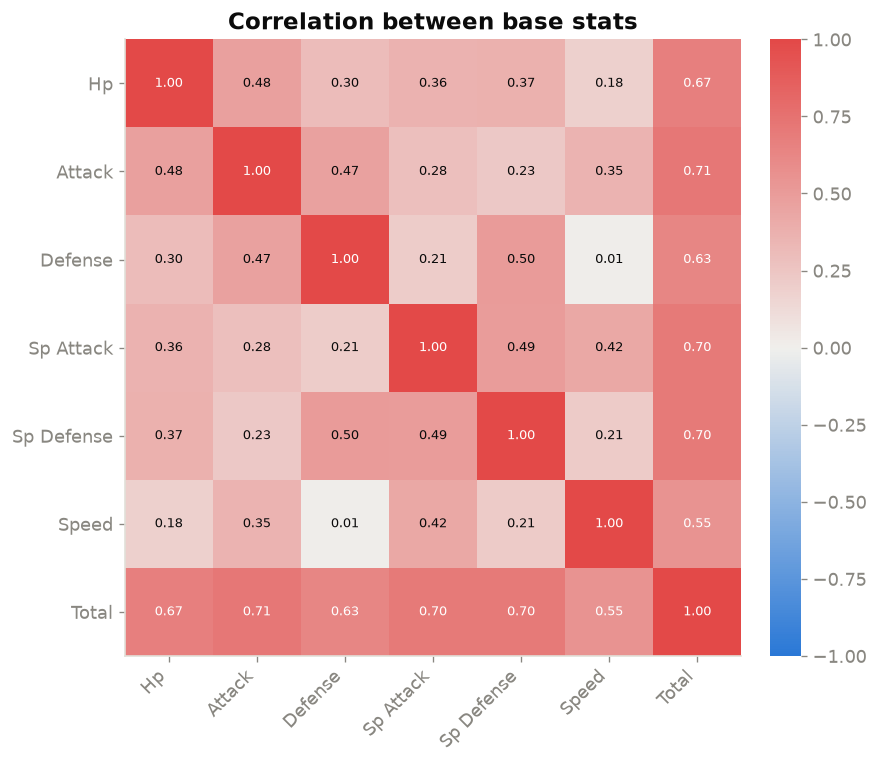

In [8]:
from matplotlib.colors import LinearSegmentedColormap
corr = df[STATS + ["total"]].corr()
labels = [c.replace("_", " ").title() for c in corr.columns]
diverging = LinearSegmentedColormap.from_list(
    "blue_grey_red", [BLUE, "#f0efec", RED])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.55 else INK, fontsize=8)
ax.grid(False)
cb = fig.colorbar(im, fraction=0.046, pad=0.04); cb.outline.set_visible(False)
ax.set_title("Correlation between base stats")
plt.tight_layout(); plt.show()

<a id="8"></a>
## 8. Type-defence profile
The 18 `against_*` columns are pure type-chart multipliers taken *by* each Pokémon. Averaged over the roster they show which attacking types are, on the whole, most and least effective. Magnitude → a single-hue **sequential** scale.

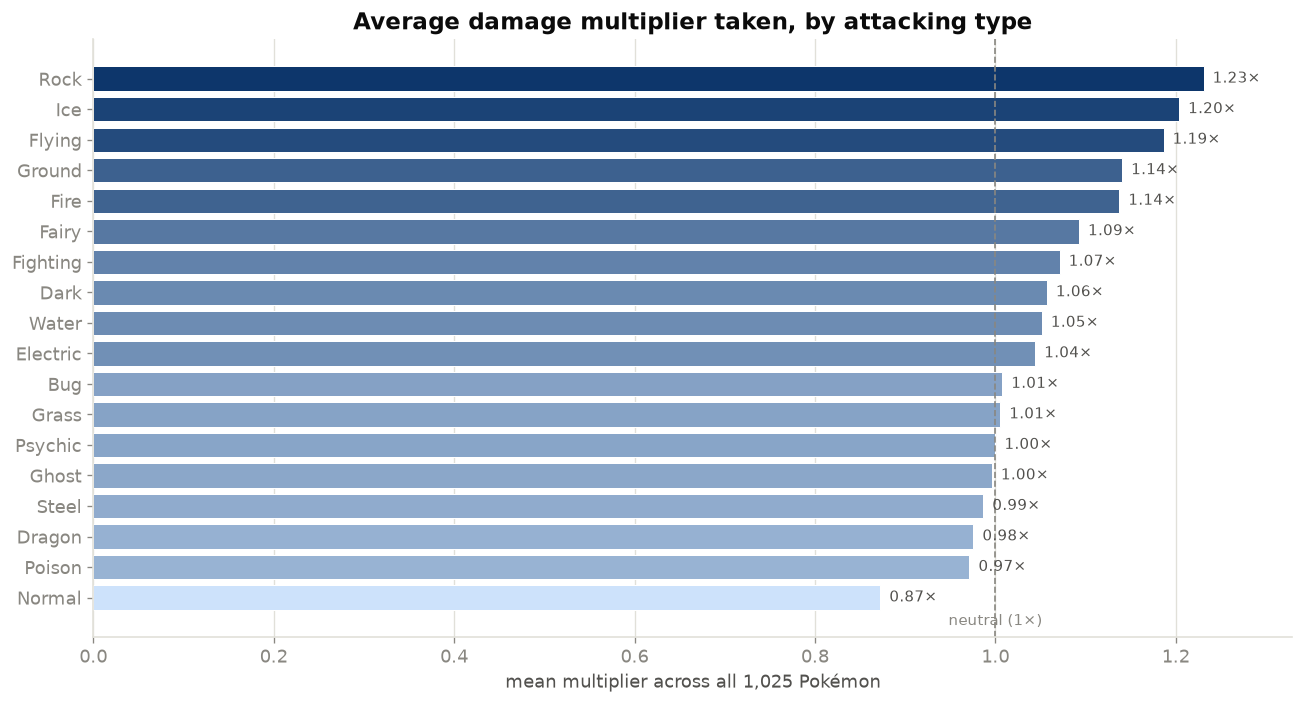

In [9]:
against = [c for c in df.columns if c.startswith("against_")]
mean_dmg = df[against].mean().sort_values()
mean_dmg.index = [c.replace("against_", "").title() for c in mean_dmg.index]

# sequential blue ramp mapped to magnitude
norm = (mean_dmg.values - mean_dmg.min()) / (mean_dmg.max() - mean_dmg.min())
seq = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#0d366b"])
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(mean_dmg.index, mean_dmg.values, color=seq(norm),
        edgecolor="white", linewidth=0.6)
ax.axvline(1.0, color=MUTED, linewidth=1, linestyle="--")
ax.text(1.0, -0.9, "neutral (1×)", color=MUTED, fontsize=9, ha="center")
for i, v in enumerate(mean_dmg.values):
    ax.text(v + 0.01, i, f"{v:.2f}×", va="center", fontsize=9, color=INK2)
ax.set_title("Average damage multiplier taken, by attacking type")
ax.set_xlabel("mean multiplier across all 1,025 Pokémon")
ax.grid(axis="y", visible=False); ax.margins(x=0.08)
plt.tight_layout(); plt.show()

<a id="9"></a>
## 9. Strongest & frailest Pokémon (by base-stat total)

In [10]:
cols = ["national_number", "english_name", "gen", "primary_type",
        "secondary_type", "total", "class"]
top = df.nlargest(15, "total")[cols].reset_index(drop=True)
bottom = df.nsmallest(15, "total")[cols].reset_index(drop=True)
print("── Top 15 by base-stat total ──")
display(top)
print("── Bottom 15 by base-stat total ──")
display(bottom)

── Top 15 by base-stat total ──


,national_number,english_name,gen,primary_type,secondary_type,total,class
0,493,Arceus,IV,normal,NaN,720,Mythical
1,890,Eternatus,VIII,poison,dragon,690,Ordinary
2,150,Mewtwo,I,psychic,NaN,680,Legendary
3,249,Lugia,II,psychic,flying,680,Legendary
4,250,Ho-Oh,II,fire,flying,680,Legendary
5,384,Rayquaza,III,dragon,flying,680,Legendary
6,483,Dialga,IV,steel,dragon,680,Legendary
7,484,Palkia,IV,water,dragon,680,Legendary
8,487,Giratina,IV,ghost,dragon,680,Legendary
9,643,Reshiram,V,dragon,fire,680,Legendary


── Bottom 15 by base-stat total ──


,national_number,english_name,gen,primary_type,secondary_type,total,class
0,746,Wishiwashi,VII,water,NaN,175,Ordinary
1,191,Sunkern,II,grass,NaN,180,Ordinary
2,824,Blipbug,VIII,bug,NaN,180,Ordinary
3,872,Snom,VIII,ice,bug,185,Ordinary
4,298,Azurill,III,normal,fairy,190,Ordinary
5,401,Kricketot,IV,bug,NaN,194,Ordinary
6,10,Caterpie,I,bug,NaN,195,Ordinary
7,13,Weedle,I,bug,poison,195,Ordinary
8,265,Wurmple,III,bug,NaN,195,Ordinary
9,280,Ralts,III,psychic,fairy,198,Ordinary


<a id="10"></a>
## 10. Takeaways & next steps

- **Water / Normal / Grass** are the most common typings; **Ice** and **Fairy** the rarest.
- The base-stat total is **bimodal** — a broad ordinary cluster and a high-stat tail of fully-evolved and legendary Pokémon; legendaries lead on *every* individual stat.
- Mean base-stat total has **drifted upward** across generations.
- Attack/Sp. Atk and Defense/Sp. Def correlate; **Speed is the most independent** stat.

**Ideas to take further with this dataset**
- Predict `is_legendary` from stats + typing (classification).
- Cluster Pokémon into archetypes (sweeper / wall / bulky-attacker) with the six stats.
- Model type-matchup advantage from the `against_*` matrix.
- Bring in the bundled artwork (`small_images/`, `large_images/`) for image tasks.

*If this helped, an upvote is appreciated — and tell me in the comments what you'd like analysed next.*